### Subgraph

LangGraph에서는 별도로 만든 그래프를 부모 그래프의 노드로 등록할 수 있다. 이렇게 다른 그래프에 포함된 그래프를 **Subgraph**라 한다.

### Subgraph를 사용하는 이유

- **재사용**: 미리 만든 그래프를 여러 워크플로우의 노드로 활용할 수 있다.
- **개발·관리 용이**: 복잡한 흐름을 역할별 그래프로 나누어 구현하고 테스트할 수 있다. 부모 그래프에서는 전체 작업 순서에 집중한다.
- **State 분리**: Subgraph가 내부 작업 데이터를 별도로 관리하고, 부모와 필요한 입력·출력만 주고받도록 구성할 수 있다.

단순한 작업은 일반 노드로도 충분하다. Subgraph는 여러 단계로 구성된 작업 흐름을 하나의 단위로 묶어 관리하거나 재사용할 때 장점이 크다.

In [1]:
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

load_dotenv()

MODEL_NAME = "gemini-3.6-flash"
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

### 같은 State 스키마를 공유하는 경우

부모와 Subgraph의 State 스키마가 같으면, **컴파일된 그래프를 그대로 `add_node`에 전달**하면 된다.

부모와 두 Subgraph는 `messages`와 `research` 필드를 가진 같은 `AgentState`를 사용한다. 같은 State 스키마를 사용해도 각 노드는 필요한 필드만 갱신할 수 있다.

- `messages`: 사용자 요청과 최종 보고서를 저장한다.
- `research`: 리서치 Subgraph가 조사 결과를 저장하고, 작성 Subgraph가 보고서 작성에 사용한다.

노드가 반환하는 값은 State의 변경분이다. 반환하지 않은 필드는 기존 값을 유지한다.

In [2]:
# 공통 State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    research: str


# 리서치 Subgraph
def research_start_node(state: AgentState):
    print("리서치 작업을 시작합니다.")
    return {}


def research_node(state: AgentState):
    system = SystemMessage(content="너는 리서치 전문가다. 주어진 주제의 핵심 사실 3개를 정리해.")
    messages = [system] + state["messages"]
    response = llm.invoke(messages)
    return {"research": response.text}

research_builder = StateGraph(AgentState)
research_builder.add_node("research_start", research_start_node)
research_builder.add_node("research", research_node)
research_builder.add_edge(START, "research_start")
research_builder.add_edge("research_start", "research")
research_builder.add_edge("research", END)
research_graph = research_builder.compile()

In [3]:
# 작성 Subgraph
def writing_node(state: AgentState):
    system = SystemMessage(content="너는 보고서 작성 전문가다. 사용자 요청과 조사 결과를 바탕으로 간결한 보고서를 작성해.")
    request = HumanMessage(
        content=f"다음 조사 결과로 보고서를 작성해.\n\n{state['research']}"
    )
    messages = [system] + state["messages"] + [request]
    response = llm.invoke(messages)
    return {"messages": [response]}

writing_builder = StateGraph(AgentState)
writing_builder.add_node("write", writing_node)
writing_builder.add_edge(START, "write")
writing_builder.add_edge("write", END)
writing_graph = writing_builder.compile()

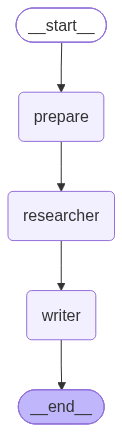

In [4]:
# 부모 그래프: Subgraph를 노드로 등록
def prepare_node(state: AgentState):
    print("요청 처리를 시작합니다.")
    return {}


parent_builder = StateGraph(AgentState)

# 일반 노드
parent_builder.add_node("prepare", prepare_node)

# 컴파일된 그래프를 그대로 노드로 추가한다
parent_builder.add_node("researcher", research_graph)
parent_builder.add_node("writer", writing_graph)

parent_builder.add_edge(START, "prepare")
parent_builder.add_edge("prepare", "researcher")
parent_builder.add_edge("researcher", "writer")
parent_builder.add_edge("writer", END)

parent_graph = parent_builder.compile()

display(Image(parent_graph.get_graph().draw_mermaid_png()))

### Subgraph 실행 과정 스트리밍

기본값인 `subgraphs=False`에서는 부모 그래프의 노드 결과만 받는다. 이때 Subgraph는 부모 그래프의 노드 하나로 표시된다. `subgraphs=True`를 지정하면 부모 그래프뿐 아니라 내부 Subgraph의 노드에서 발생한 결과도 함께 받을 수 있다.

`subgraphs=False`에서는 `chunk`를 반환하고, `subgraphs=True`에서는 `(namespace, chunk)`를 반환한다.

- `namespace`: 이벤트가 발생한 그래프의 경로이다.
- `chunk`: 해당 실행 단계에서 변경된 State이다. `stream_mode="updates"`에서는 `{노드 이름: 변경된 State}` 형태로 전달된다.

두 실행 결과를 비교하면 Subgraph 내부 노드가 스트림에 추가되는 것을 확인할 수 있다.

### Subgraph 내부 실행 제외

In [ ]:
for chunk in parent_graph.stream(
    {"messages": [HumanMessage(content="LangGraph의 Subgraph 기능에 대해 정리해줘.")]},
    subgraphs=False,
    stream_mode="updates",
):
    for node_name, state in chunk.items():
        print("=" * 60)
        print("Graph: parent_graph")
        print(f"Node: {node_name}")
        if state and state.get("research"):
            print(f"research: {state['research'][:300]}")
        if state and state.get("messages"):
            print(f"messages: {state['messages'][-1].text[:300]}")
        if not state:
            print(state)
        print()

### Subgraph 내부 실행 포함

In [ ]:
for namespace, chunk in parent_graph.stream(
    {"messages": [HumanMessage(content="LangGraph의 Subgraph 기능에 대해 정리해줘.")]},
    subgraphs=True,
    stream_mode="updates",
):
    for node_name, state in chunk.items():
        print("=" * 60)
        print(f"Graph: {namespace}")
        print(f"Node: {node_name}")
        if state and state.get("research"):
            print(f"research: {state['research'][:300]}")
        if state and state.get("messages"):
            print(f"messages: {state['messages'][-1].text[:300]}")
        if not state:
            print(state)
        print()

### 부모와 Subgraph의 State가 다른 경우

앞에서는 부모와 Subgraph가 같은 State 스키마를 공유했다. State 전체 구조가 달라도, 주고받을 필드의 이름과 데이터 형식이 호환되면 **컴파일된 Subgraph를 그대로 `add_node`에 전달**할 수 있다.

부모와 Subgraph가 주고받을 데이터의 필드 이름이나 형식이 다르면, **래퍼 함수**에서 입력·출력을 변환한다.

- **필드 이름이 다른 경우**: 부모의 `analysis_result`와 Subgraph의 `analysis`처럼 같은 데이터를 서로 다른 이름으로 저장할 때
- **데이터 형식이 다른 경우**: 부모는 `messages`에 메시지 목록을 저장하지만, Subgraph는 `request`에 요청 문자열을 받을 때

기존 그래프를 다른 State 구조의 부모 그래프에서 재사용할 때 이러한 변환이 필요할 수 있다.

다음 예제는 사용자가 요청한 주제를 분석한 뒤 보고서로 작성한다. 래퍼 함수는 부모의 마지막 사용자 메시지를 Subgraph의 `request`로 전달하고, 반환된 `analysis`를 부모의 `analysis_result`에 저장한다. 최종 보고서는 `messages`에 추가한다.

In [5]:
# Subgraph State
class AnalysisState(TypedDict):
    request: str
    analysis: str


def analysis_node(state: AnalysisState):
    system = SystemMessage(content="사용자가 요청한 주제를 분석하여 핵심 쟁점 3개와 각각의 장단점을 정리해.")
    response = llm.invoke([system, HumanMessage(content=state["request"])])
    return {"analysis": response.text}


analysis_builder = StateGraph(AnalysisState)
analysis_builder.add_node("analyze", analysis_node)
analysis_builder.add_edge(START, "analyze")
analysis_builder.add_edge("analyze", END)
analysis_graph = analysis_builder.compile()

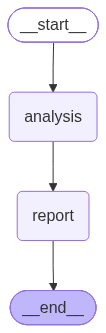

In [6]:
# 부모 State
class ParentState(TypedDict):
    messages: Annotated[list, add_messages]
    analysis_result: str


# 래퍼 함수: 부모 State → Subgraph State → 부모 State
def analysis_wrapper(state: ParentState):
    sub_input = {"request": state["messages"][-1].text}
    sub_result = analysis_graph.invoke(sub_input)
    return {"analysis_result": sub_result["analysis"]}


def report_node(state: ParentState):
    system = SystemMessage(content="분석 결과를 바탕으로 간결한 보고서를 작성해.")
    response = llm.invoke([system, HumanMessage(content=state["analysis_result"])])
    return {"messages": [response]}


parent_builder = StateGraph(ParentState)
parent_builder.add_node("analysis", analysis_wrapper)  # 래퍼 함수를 노드로 등록
parent_builder.add_node("report", report_node)
parent_builder.add_edge(START, "analysis")
parent_builder.add_edge("analysis", "report")
parent_builder.add_edge("report", END)

diff_state_graph = parent_builder.compile()
display(Image(diff_state_graph.get_graph().draw_mermaid_png()))

In [ ]:
for namespace, chunk in diff_state_graph.stream(
    {"messages": [HumanMessage(content="AI Agent 도입의 장점과 한계를 분석해줘.")]},
    subgraphs=True,
    stream_mode="updates",
):
    for node_name, state in chunk.items():
        print("=" * 60)
        print(f"Graph: {namespace}")
        print(f"Node: {node_name}")
        if state and state.get("messages"):
            print(state["messages"][-1].text[:300])
        else:
            print(state)
        print()


### 실습: 학습 콘텐츠 생성 그래프

사용자가 입력한 학습 주제를 설명하고, 설명 내용을 바탕으로 확인 문제 3개를 생성하는 그래프를 구현한다.

- 부모의 `LearningState`는 `topic`, `explanation`, `quiz`를 저장한다.
- 설명 Subgraph는 부모와 같은 `LearningState`를 사용하며, `topic`을 받아 `explanation`을 갱신한다.
- 퀴즈 Subgraph는 별도의 `QuizState`를 사용하며, `source_text`를 받아 `questions`를 생성한다.
- 래퍼 함수는 `explanation`을 `source_text`로 전달하고, 반환된 `questions`를 부모의 `quiz`에 저장한다.
- 부모 그래프는 `설명 → 퀴즈 생성` 순서로 실행한다.
- `{"topic": "LangGraph의 State와 Reducer"}`를 입력하고, `subgraphs=True`로 내부 실행 과정을 확인한다.

State에는 작업 데이터를 저장하고, 각 노드는 LLM을 호출할 때 메시지를 구성한다.

In [2]:
class LearningState(TypedDict):
    topic: str
    explanation: str
    quiz: str


def explanation_node(state: LearningState):
    system = SystemMessage(
        content="너는 개념 설명 전문가다. 학습 주제를 초보자도 이해할 수 있게 설명해."
    )
    response = llm.invoke([system, HumanMessage(content=state["topic"])])
    return {"explanation": response.text}


# TODO: LearningState를 사용하는 설명 Subgraph를 만들고 컴파일한다.

explanation_builder = StateGraph(LearningState)
explanation_builder.add_node("explanation", explanation_node)
explanation_builder.add_edge(START, "explanation")
explanation_builder.add_edge("explanation", END)
explanation_graph = explanation_builder.compile()

In [3]:
class QuizState(TypedDict):
    source_text: str
    questions: str


def quiz_node(state: QuizState):
    system = SystemMessage(
        content="너는 퀴즈 출제 전문가다. 설명 내용만 활용해 확인 문제 3개를 만들어."
    )
    response = llm.invoke([system, HumanMessage(content=state["source_text"])])
    return {"questions": response.text}


# TODO: QuizState를 사용하는 퀴즈 Subgraph를 만들고 컴파일한다.
quiz_builder = StateGraph(QuizState)
quiz_builder.add_node("quiz", quiz_node)
quiz_builder.add_edge(START, "quiz")
quiz_builder.add_edge("quiz", END)
quiz_graph = quiz_builder.compile()

# TODO: 래퍼 함수에서 explanation을 source_text로 전달하여 퀴즈 Subgraph를 호출하고,
#       반환된 questions를 부모 State의 quiz에 저장한다.

def quiz_wrapper(state: LearningState):
    explanation = state["explanation"]
    sub_input = {"source_text" : explanation}
    sub_result = quiz_graph.invoke(sub_input)
    return {"quiz" : sub_result["questions"]}

In [4]:
# TODO: 설명 Subgraph와 퀴즈 래퍼를 부모 그래프의 노드로 등록한다.
parent_builder = StateGraph(LearningState)
parent_builder.add_node("explanation", explanation_graph)
parent_builder.add_node("quiz", quiz_wrapper)

# TODO: START → 설명 → 퀴즈 → END 순서로 연결하고 컴파일한다.
parent_builder.add_edge(START, "explanation")
parent_builder.add_edge("explanation", "quiz")
parent_builder.add_edge("quiz", END)

parent_graph = parent_builder.compile()

# TODO: 완성한 그래프를 subgraphs=True, stream_mode="updates"로 실행한다.
# 입력: {"topic": "LangGraph의 State와 Reducer"}
# 각 이벤트의 namespace, 노드 이름, State 변경분을 출력한다.

for namespace, chunk in parent_graph.stream(
    {"topic": "LangGraph의 State와 Reducer"},
    subgraphs=True,
    stream_mode="updates",
):
    for node_name, state in chunk.items():
        print("=" * 60)
        print(f"Graph: {namespace}")
        print(f"Node: {node_name}")
        if state and state.get("explanation"):
            print(f"explanation: {state['explanation'][:300]}")

        if state and state.get("quiz"):
            print(f"quiz: {state['quiz'][:300]}")

        if state and state.get("questions"):
            print(f"questions: {state['questions'][:300]}")

        if not state:
            print(state)

        print()


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Graph: ('explanation:69c207ee-3bf2-7fec-4c36-df0ef24c6697',)
Node: explanation
explanation: LangGraph를 처음 접할 때 가장 중요한 두 가지 핵심 개념이 바로 **State(상태)**와 **Reducer(리듀서)**입니다. 

초보자의 눈높이에 맞춰 **'이어달리기 경주'**와 **'공유 바인더 노트'** 비유를 통해 아주 쉽게 설명해 드릴게요!

---

### 1. State (상태) : "모두가 공유하는 프로젝트 노트"

LangGraph에서 **State**는 그래프 안의 모든 작업자(AI, 함수, 도구 등)가 **함께 돌려보는 '공유 노트'**입니다.

* **왜 필요한가요?** 
  AI가 여러 단계에 걸

Graph: ()
Node: explanation
explanation: LangGraph를 처음 접할 때 가장 중요한 두 가지 핵심 개념이 바로 **State(상태)**와 **Reducer(리듀서)**입니다. 

초보자의 눈높이에 맞춰 **'이어달리기 경주'**와 **'공유 바인더 노트'** 비유를 통해 아주 쉽게 설명해 드릴게요!

---

### 1. State (상태) : "모두가 공유하는 프로젝트 노트"

LangGraph에서 **State**는 그래프 안의 모든 작업자(AI, 함수, 도구 등)가 **함께 돌려보는 '공유 노트'**입니다.

* **왜 필요한가요?** 
  AI가 여러 단계에 걸

Graph: ('quiz:19add4db-63c9-f644-0627-e04ddadcd6ff',)
Node: quiz
questions: 제공해주신 설명 내용을 바탕으로 만든 **확인 문제 3개**입니다.

---

### [확인 문제]

**Q1. LangGraph에서 여러 작업자(AI, 함수 등)가 이전 단계의 작업 내용을 기억하고 서로 돌려보는 '공유 노트'이자 '기억 상자' 역할을 하는 핵심 개념은 무엇일까요?**

* **정답:** **State (상태)**
